# Guide pour l'Appel à une API Hugging Face pour la Segmentation d'Images

Bienvenue ! Ce notebook a pour but de vous guider pas à pas dans l'utilisation de l'API d'inférence de Hugging Face pour effectuer de la segmentation d'images. La segmentation d'images consiste à attribuer une étiquette (comme "cheveux", "vêtement", "arrière-plan") à chaque pixel d'une image.

Nous allons :
1. Comprendre ce qu'est une API et comment s'y connecter.
2. Envoyer une image à un modèle de segmentation hébergé sur Hugging Face.
3. Récupérer et interpréter les résultats.
4. Visualiser les masques de segmentation.
5. Étendre cela pour traiter plusieurs images.

## 1. Configuration Initiale et Importations

Commençons par importer les bibliothèques Python nécessaires. Nous aurons besoin de :
- `os` pour interagir avec le système de fichiers (lister les images).
- `requests` pour effectuer des requêtes HTTP vers l'API.
- `PIL (Pillow)` pour manipuler les images.
- `matplotlib.pyplot` pour afficher les images et les masques.
- `numpy` pour la manipulation des tableaux (les images sont des tableaux de pixels).
- `tqdm.notebook` pour afficher une barre de progression (utile pour plusieurs images).
- `base64` et `io` pour décoder les masques renvoyés par l'API.

In [1]:
import os
from PIL import Image
import numpy as np
from tqdm.notebook import tqdm
from dotenv import load_dotenv # manage .env vars
import lib

if not load_dotenv():
    print("\nUne erreur s'est produite lors du chargement du fichier d'environnement .env, vérifiez qu'il existe (copiez depuis .env.dist)")

### Variables de Configuration

Nous devons définir quelques variables :
- `image_dir`: Le chemin vers le dossier contenant vos images. **Assurez-vous de modifier ce chemin si nécessaire.**
- `max_images`: Le nombre maximum d'images à traiter (pour ne pas surcharger l'API ou attendre trop longtemps).
- `api_token`: Votre jeton d'API Hugging Face. **IMPORTANT : Gardez ce jeton secret !**

**Comment obtenir un token API Hugging Face ?**
1. Créez un compte sur [huggingface.co](https://huggingface.co/).
2. Allez dans votre profil -> Settings -> Access Tokens.
3. Créez un nouveau token (par exemple, avec le rôle "read").
4. Copiez ce token ici.

In [2]:
image_dir = "/workspace/images"
max_images = 3

# Retrieve API Token from .env
api_token = os.getenv('API_TOKEN')

# Create images/ folder if not exists
if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Dossier '{image_dir}' créé. Veuillez y ajouter des images .jpg ou .png.")
else:
    print(f"Dossier '{image_dir}' existant.")

if api_token == "YourApiToken":
    print("\nATTENTION : Vous devez remplacer 'YourApiToken' par votre token API personnel : modifiez le fichier .env, précédemment copié depuis .env.dist.")

Dossier '/workspace/images' existant.


## 2. Comprendre l'API d'Inférence Hugging Face

L'API d'inférence permet d'utiliser des modèles hébergés sur Hugging Face sans avoir à les télécharger ou à gérer l'infrastructure.

- **Modèle utilisé** : Nous allons utiliser le modèle `sayeed99/segformer_b3_clothes`, spécialisé dans la segmentation de vêtements et de parties du corps.
- **URL de l'API** : `https://api-inference.huggingface.co/models/sayeed99/segformer_b3_clothes`
- **Headers (En-têtes)** : cf `lib/model`
    - `Authorization`: Contient notre token API, fourni à la fonction `request_for_image`
    - `Content-Type`: auto complété par la fonction `request_for_image` en fonction du type d'image

In [3]:
import glob

# Images à traiter
image_paths = glob.glob(os.path.join(image_dir, '*.jpg')) + \
              glob.glob(os.path.join(image_dir, '*.jpeg')) + \
              glob.glob(os.path.join(image_dir, '*.png'))

if not image_paths:
    print(f"Aucune image trouvée dans '{image_dir}'. Veuillez y ajouter des images.")
else:
    print(f"{len(image_paths)} image(s) à traiter : {image_paths}")

3 image(s) à traiter : ['/workspace/images/chemisebleue.jpg', '/workspace/images/polobleu.jpg', '/workspace/images/course.jpg']


## 3. Fonctions Utilitaires pour le Traitement des Masques

**Le code a été déplacé pour plus de lisibilité, dans**
 * `lib/image.py`pour le traitement générique d'images
 * `lib/model/segformer_b3_clothes.py`pour les traitements spécifiques au modèle

Le modèle que nous utilisons (`sayeed99/segformer_b3_clothes`) renvoie des masques pour différentes classes (cheveux, chapeau, etc.). Ces masques sont encodés en base64. Les fonctions ci-dessous sont fournies pour vous aider à :
1.  `CLASS_MAPPING`: Un dictionnaire qui associe les noms de classes (ex: "Hat") à des identifiants numériques.
2.  `get_image_dimensions`: Récupérer les dimensions d'une image.
3.  `decode_base64_mask`: Décoder un masque de base64 en une image (tableau NumPy) et le redimensionner.
4.  `create_masks`: Combiner les masques de toutes les classes détectées en un seul masque de segmentation final, où chaque pixel a la valeur de l'ID de sa classe.

**Cette partie est donnée car elle est spécifique au format de sortie de ce modèle et un peu complexe pour une première approche.** Lisez-la pour comprendre son rôle, mais ne vous attardez pas sur les détails d'implémentation pour l'instant.

## 4. Segmentation d'une Seule Image

Avant de traiter toutes les images, concentrons-nous sur une seule pour bien comprendre le processus.

Étapes :
1.  Choisir une image.
2.  Ouvrir l'image en mode binaire (`"rb"`) et lire son contenu (`data`).
3.  Déterminer le `Content-Type` (par exemple, `"image/jpeg"` ou `"image/png"`).
4.  Envoyer la requête POST à l'API avec `requests.post()` en passant l'URL, les headers et les données.
5.  Vérifier le code de statut de la réponse. Une erreur sera levée si le code n'est pas 2xx (succès) grâce à `response.raise_for_status()`.
6.  Convertir la réponse JSON en un dictionnaire Python avec `response.json()`.
7.  Utiliser nos fonctions `get_image_dimensions` et `create_masks` pour obtenir le masque final.
8.  Afficher l'image originale et le masque segmenté.

Traitement de l'image : /workspace/images/course.jpg
Api Response HTTP Code: 200


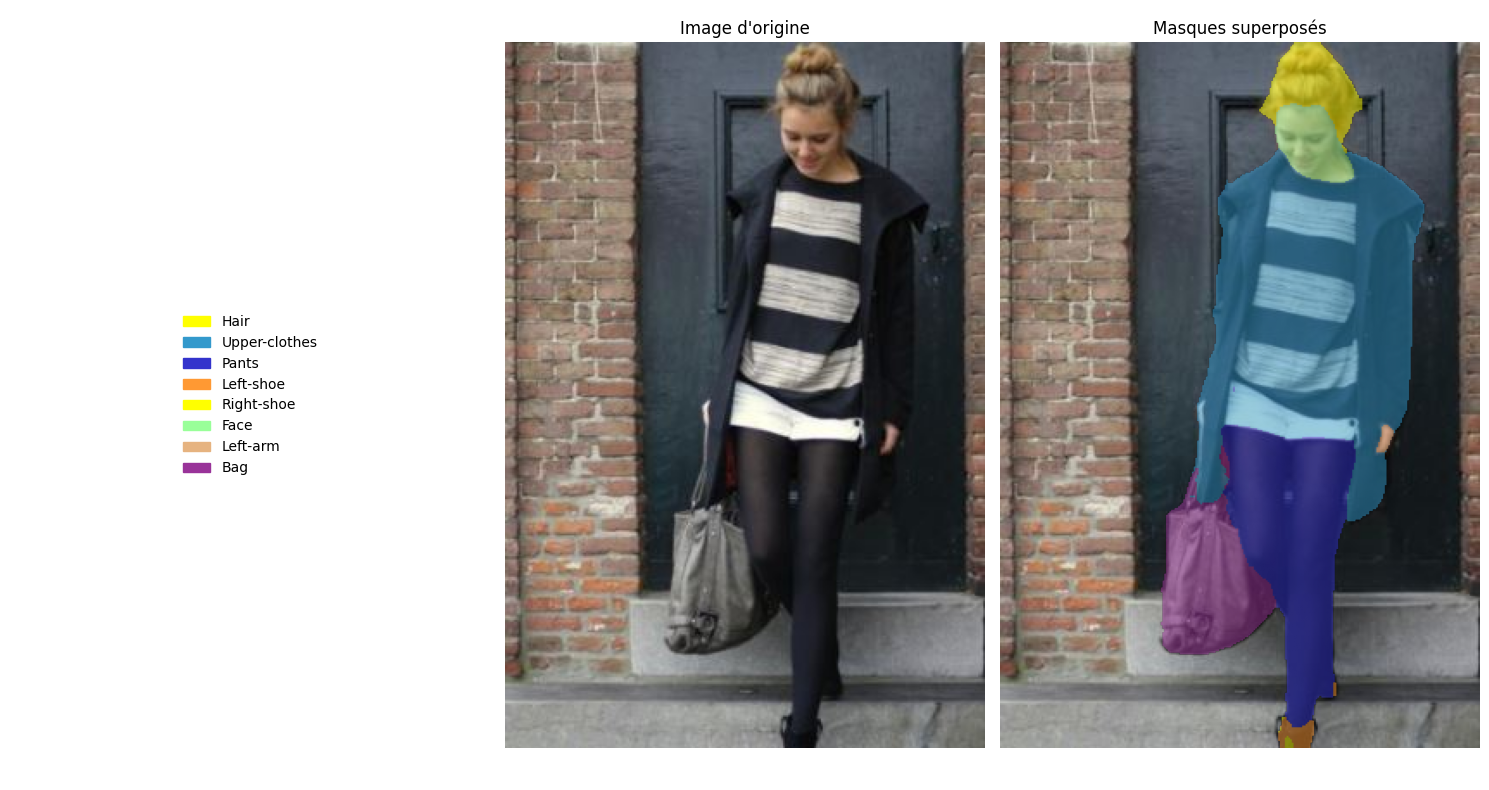

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

if image_paths:
    single_image_path = image_paths[2]
    print(f"Traitement de l'image : {single_image_path}")

    try:
        # 1. Appel à l'API
        computed_image = lib.request_for_image(single_image_path, api_token)

        # 2. Création du masque
        original_img = Image.open(single_image_path).convert("RGB")
        width, height = lib.get_image_dimensions(single_image_path)
        final_masks = lib.create_masks(computed_image, width, height)

        # Créer une figure avec 1 ligne et 3 colonnes
        fig, axes = plt.subplots(1, 3, figsize=(15, 8))
        
        # Afficher chaque élément dans un subplot
        lib.display_legend(final_masks, ax=axes[0])
        lib.display_image(original_img, ax=axes[1])
        lib.display_masks(original_img, final_masks, ax=axes[2])
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Une erreur est survenue : {e}")
else:
    print("Aucune image à traiter. Vérifiez la configuration de 'image_dir' et 'max_images'.")

## 5. Segmentation de Plusieurs Images (Batch)

Maintenant que nous savons comment traiter une image, nous pouvons créer une fonction pour en traiter plusieurs.
Cette fonction va boucler sur la liste `image_paths` et appliquer la logique de segmentation à chaque image.
Nous utiliserons `tqdm` pour avoir une barre de progression.

In [5]:
# Appel avec affichage automatique de la barre
if image_paths:
    print(f"\nTraitement de {len(image_paths)} image(s) en batch...")
    batch_seg_results = lib.segment_images_batch(image_paths, api_token)
    print("✅ Traitement en batch terminé.")
else:
    batch_seg_results = []
    print("Aucune image à traiter en batch.")


Traitement de 3 image(s) en batch...


🟢 Segmentation:   0% 0/3 [00:00<?, ?img/s]

Api Response HTTP Code: 200


🟢 Segmentation:  33% 1/3 [00:01<00:03,  1.70s/img]

Api Response HTTP Code: 200


🟢 Segmentation:  67% 2/3 [00:03<00:01,  1.75s/img]

Api Response HTTP Code: 200


🟢 Segmentation: 100% 3/3 [00:04<00:00,  1.65s/img]

✅ Traitement en batch terminé.


## 6. Affichage des Résultats en Batch

Nous allons maintenant créer une fonction pour afficher les images originales et leurs segmentations correspondantes côte à côte, dans une grille.

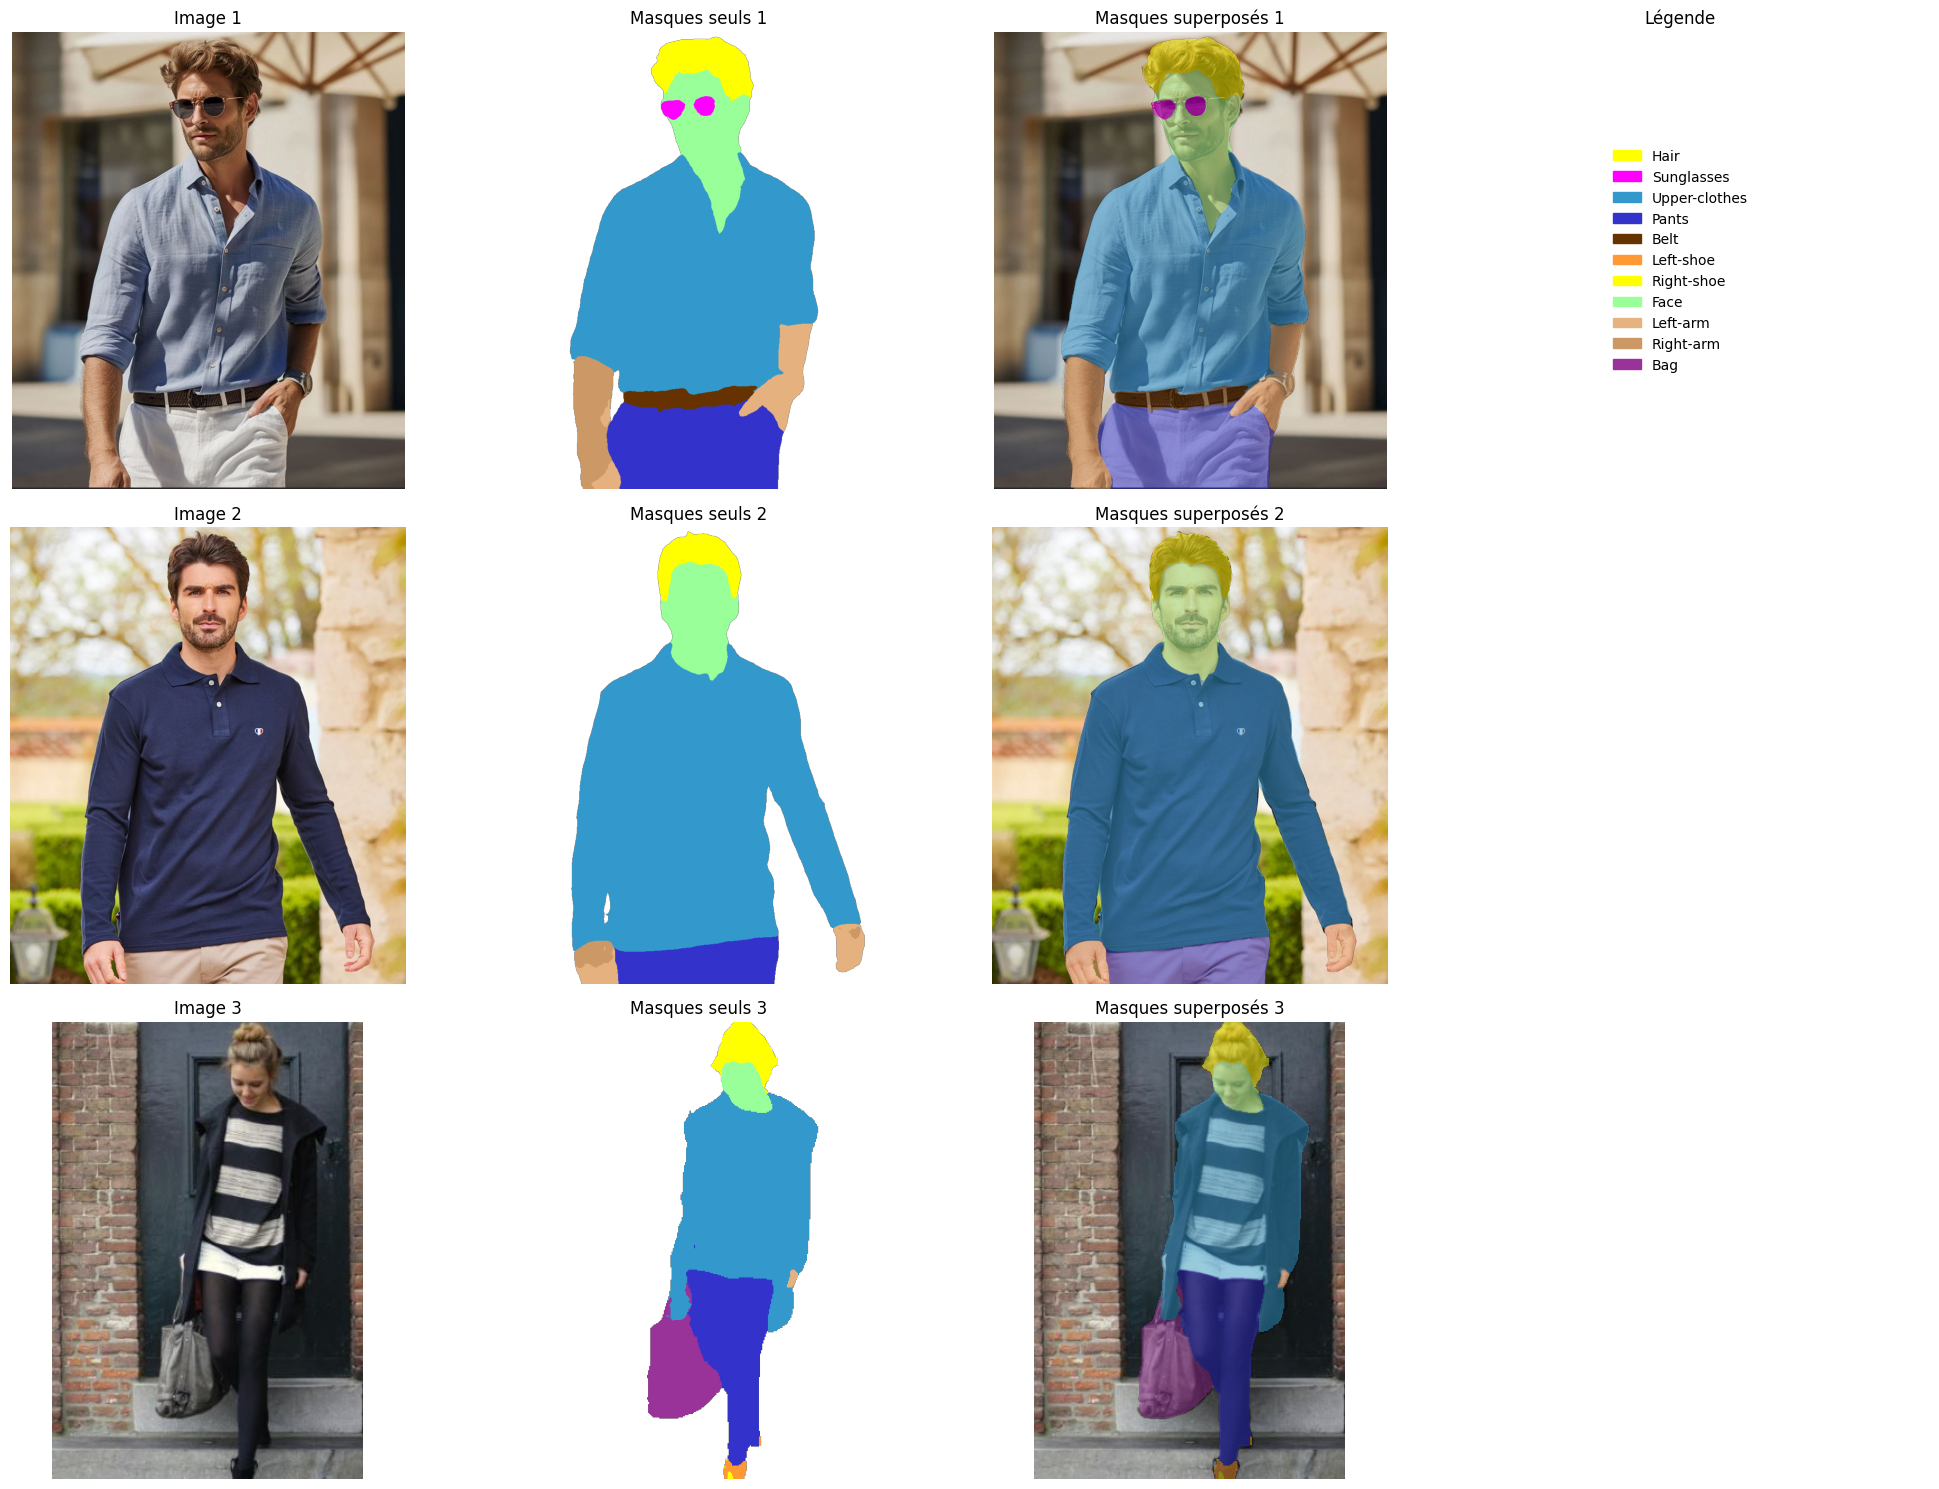

In [6]:
# call display images
lib.display_images_grid(image_paths, batch_seg_results)

## Conclusion et Prochaines Étapes

Félicitations ! Vous avez appris à :
- Configurer les appels à l'API d'inférence Hugging Face.
- Envoyer des images pour la segmentation.
- Interpréter les résultats (avec l'aide des fonctions fournies).
- Visualiser les segmentations.

Pistes d'amélioration ou d'exploration :
- **Gestion d'erreurs plus fine** : Implémenter des tentatives multiples (retry) en cas d'échec de l'API (par exemple, si le modèle est en cours de chargement).
- **Appels asynchrones** : Pour un grand nombre d'images, des appels asynchrones (avec `asyncio` et `aiohttp`) seraient beaucoup plus rapides.
- **Autres modèles** : Explorer d'autres modèles de segmentation ou d'autres tâches sur Hugging Face Hub.

N'hésitez pas à modifier le code, à tester avec vos propres images et à explorer davantage !

**_Note_** : Si vous aimez ce modèle, n'hésitez pas à le [télécharger](https://huggingface.co/sayeed99/segformer_b3_clothes) et jouer avec directement sur votre machine !